# Including Conditional Variables

The hypernetwork $f_\phi$ maps a stochastic latent code $z \sim p(z)$ to a set of weights $\theta = f_\phi(z)$, which parameterize a base model. By default, the only source of variation in the generated weights is the random draw of $z$.

**Conditional variables** extend this by concatenating an observed condition vector $C$ to the latent code before passing it through $f_\phi$:

$$\theta = f_\phi([z, C])$$

This allows a single hypernetwork to produce *different families of weight distributions* depending on $C$. Useful applications include:

- **Multi-task learning** — one hypernetwork serves several related tasks, selected by $C$.
- **Domain adaptation** — $C$ encodes the source domain.
- **Conditional generation** — steer the predictive distribution with side information.

In this notebook we demonstrate the idea with a simple synthetic example: **5 different polynomial curves**, where a one-hot encoding of the polynomial label serves as $C$. We learn a **conditional regression**—given input $x$ and condition $C$, the hypernetwork generates weights that produce the correct $y = \text{poly}_k(x)$.

In [50]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from hnet.models.MLP import MLP
from hnet.models.HyperNet import HyperNet

%load_ext autoreload
%autoreload 2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using {device}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using cuda


## 1. Synthetic Data

We create 5 polynomial curves $y = a_k x^2 + b_k x + c_k$, each with distinct coefficients. For each polynomial we sample $(x, y)$ pairs with $x$ drawn uniformly and $y$ computed from the polynomial plus small Gaussian noise. We store a **one-hot label** indicating which polynomial generated each point — this will be the conditional variable $C$.

In [51]:
torch.manual_seed(42)

N_POLYNOMIALS = 5
N_POINTS = 200
X_MIN, X_MAX = -3.0, 3.0
NOISE_STD = 0.15

# Polynomial coefficients: y = a*x^2 + b*x + c
poly_coeffs = [
    (0.3, -0.5, 5.0),   # gentle upward parabola
    (-0.4, 0.0, 1.0),   # downward parabola
    (0.1, 1.0, -2.0),   # even gentler + linear
    (-0.2, -0.8, 0.0),  # inverted, shifted
    (0.5, 0.5, -10.0),   # steep upward
]

def eval_poly(x, a, b, c):
    return a * x**2 + b * x + c

all_x, all_y, all_labels = [], [], []
for k in range(N_POLYNOMIALS):
    a, b, c = poly_coeffs[k]
    x = torch.rand(N_POINTS, device='cpu') * (X_MAX - X_MIN) + X_MIN
    y = eval_poly(x, a, b, c) + torch.randn(N_POINTS, device='cpu') * NOISE_STD
    all_x.append(x.unsqueeze(-1))
    all_y.append(y.unsqueeze(-1))
    all_labels.append(torch.full((N_POINTS,), k, dtype=torch.long))

X = torch.cat(all_x, dim=0)                 # (1000, 1)
Y = torch.cat(all_y, dim=0)                 # (1000, 1)
labels = torch.cat(all_labels, dim=0)       # (1000,)
C_all = torch.nn.functional.one_hot(labels, num_classes=N_POLYNOMIALS).float()

print(f'X shape:      {X.shape}')
print(f'Y shape:      {Y.shape}')
print(f'Labels shape:  {labels.shape}')
print(f'C shape:       {C_all.shape}')

X shape:      torch.Size([1000, 1])
Y shape:      torch.Size([1000, 1])
Labels shape:  torch.Size([1000])
C shape:       torch.Size([1000, 5])


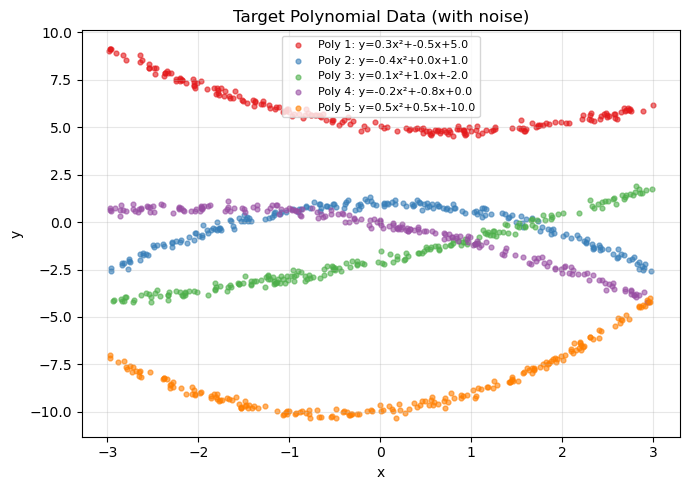

In [52]:
COLORS = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

fig, ax = plt.subplots(figsize=(7, 5))
for k in range(N_POLYNOMIALS):
    x_k = all_x[k].squeeze()
    y_k = all_y[k].squeeze()
    a, b, c = poly_coeffs[k]
    ax.scatter(x_k.numpy(), y_k.numpy(), c=COLORS[k], s=12, alpha=0.6,
              label=f'Poly {k+1}: y={a:.1f}x²+{b:.1f}x+{c:.1f}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Target Polynomial Data (with noise)')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Model Setup

The **base model** is a tiny MLP that maps input $x \in \mathbb{R}$ to output $\hat{y} \in \mathbb{R}$—a 1-D to 1-D regression. All the expressive power comes from the weights that the hypernetwork generates.

The **hypernetwork** is configured with `cond_dim=5` so that the $\phi$-network's input layer has size `stochastic_channels + 5`. At each forward pass:

1. Sample $z \sim p(z)$
2. Concatenate the one-hot condition: $[z, C]$
3. Produce weights: $\theta = f_\phi([z, C])$
4. Evaluate the base model: $\hat{y} = f_\theta(x)$

Because different values of $C$ shift the input to $f_\phi$, the hypernetwork can learn to generate weights that implement different polynomial fits for each condition.

In [53]:
base_model = MLP(in_channels=1, out_channels=1,
                 hidden_channels=64, layers=2, nonlin='elu')

model = HyperNet(base_model,
                 stochastic_channels=32,
                 width=128,
                 cond_dim=N_POLYNOMIALS,
                 nonlin='elu',
                 pz='bernoulli').to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'Total hypernetwork parameters: {n_params:,}')

Total hypernetwork parameters: 1,119,297


## 3. Training

We train with **MSE loss** for regression. For each polynomial $k$:

1. Construct the one-hot $C_k$.
2. Feed a batch of $(x, y)$ pairs from polynomial $k$—the base model receives $x$ as input.
3. The hypernetwork produces an ensemble of predictions $\{\hat{y}_s\}_{s=1}^{S}$ conditioned on $C_k$.
4. We minimize the mean squared error between the ensemble mean (or each sample) and the target $y$.

Because $C$ differs across the 5 polynomials, the hypernetwork learns to map each one-hot condition to a different family of weights.

In [54]:
crit = torch.nn.MSELoss()
optim = torch.optim.Adam(model.parameters(), lr=1e-4)

N_EPOCHS = 250
N_SAMPLES = 100
BATCH_SIZE = 256

losses = []
for epoch in range(N_EPOCHS):
    epoch_loss = 0.0
    n_batches = 0

    for k in range(N_POLYNOMIALS):
        mask = labels == k
        x_k = X[mask].to(device)
        y_k = Y[mask].to(device)

        C_k = torch.zeros(N_POLYNOMIALS, device=device)
        C_k[k] = 1.0

        for idx in torch.split(torch.randperm(y_k.size(0), device=device), BATCH_SIZE):
            optim.zero_grad()

            x_batch = x_k[idx]
            yhat = model(x_batch, samples=N_SAMPLES, C=C_k)
            # Use mean over samples for regression target
            yhat_mean = yhat.mean(dim=0)
            loss = crit(yhat_mean, y_k[idx])
            loss.backward()
            optim.step()

            epoch_loss += loss.item()
            n_batches += 1

    avg_loss = epoch_loss / n_batches
    losses.append(avg_loss)

    if (epoch + 1) % 25 == 0:
        print(f'Epoch {epoch+1:>4d}/{N_EPOCHS} — loss: {avg_loss:.4f}')

print('Done.')

Epoch   25/250 — loss: 0.7301
Epoch   50/250 — loss: 0.5379
Epoch   75/250 — loss: 0.4038
Epoch  100/250 — loss: 0.3218
Epoch  125/250 — loss: 0.2351
Epoch  150/250 — loss: 0.2964
Epoch  175/250 — loss: 0.1637
Epoch  200/250 — loss: 0.3571
Epoch  225/250 — loss: 0.2139
Epoch  250/250 — loss: 0.0884
Done.


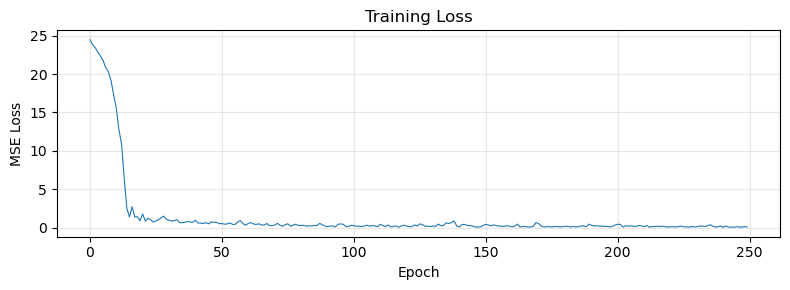

In [55]:
plt.figure(figsize=(8, 3))
plt.plot(losses, lw=0.8)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Evaluation

For each condition $C_k$ we evaluate the model on a fine grid of $x$ values. The hypernetwork produces an ensemble of predictions; we plot the mean predicted curve along with the true polynomial and the training data.

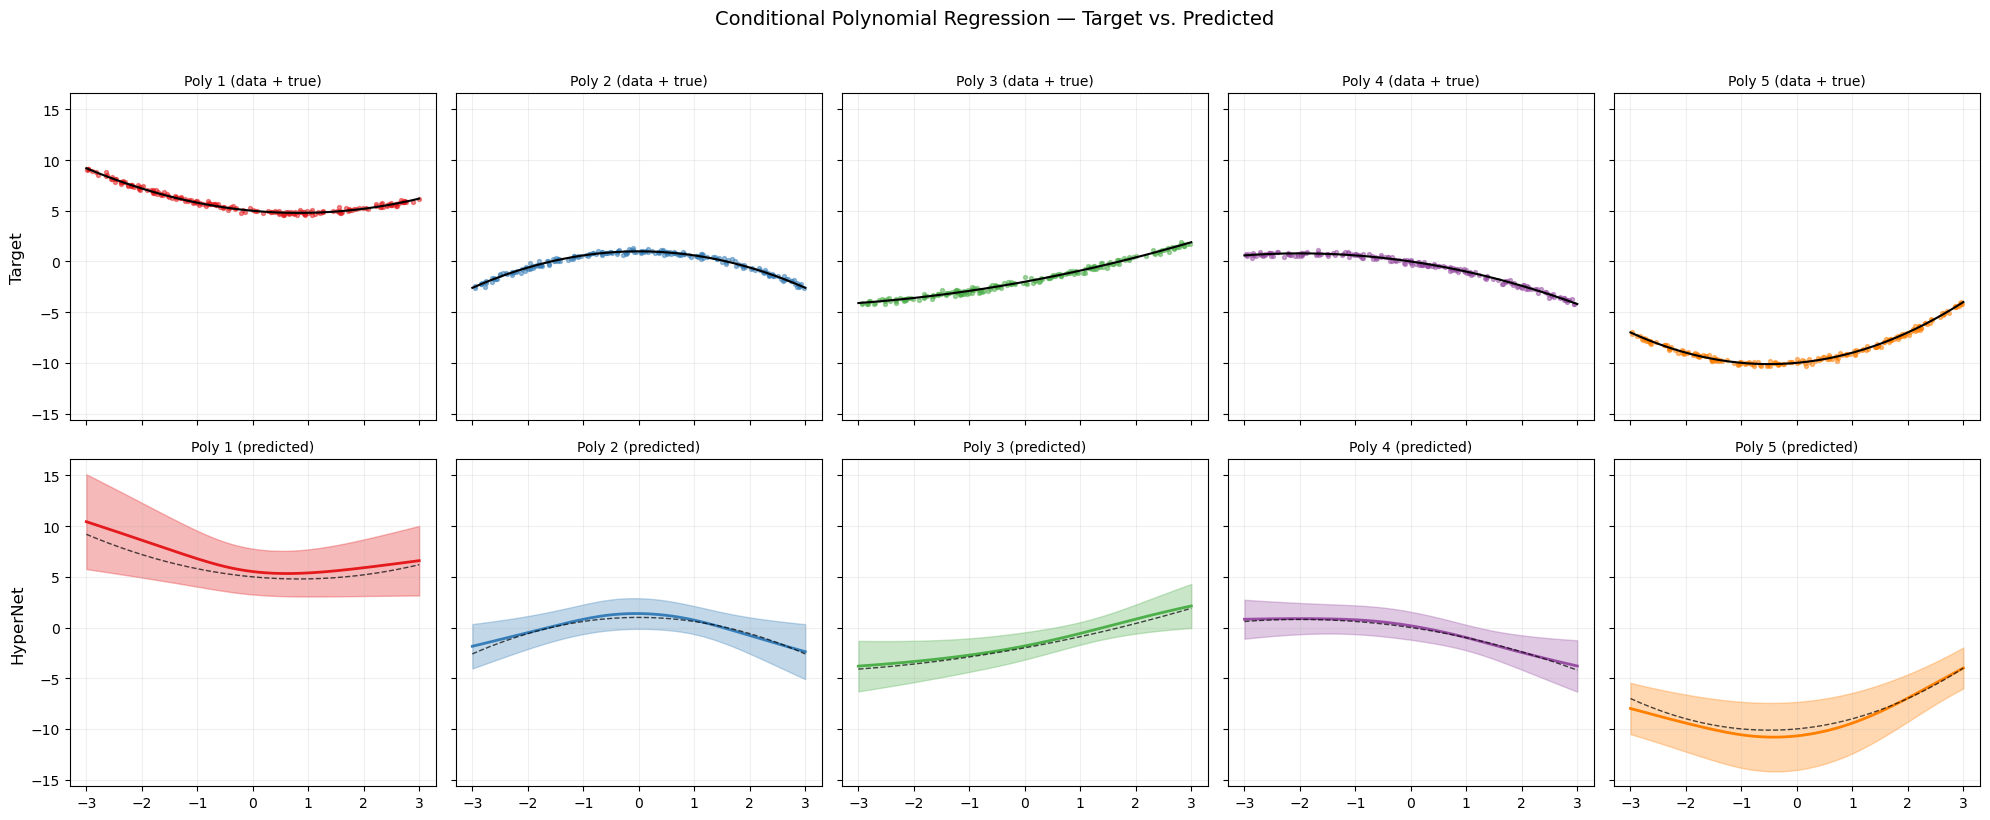

In [56]:
model.eval()

x_grid = torch.linspace(X_MIN, X_MAX, 150, device=device).unsqueeze(-1)
n_eval_samples = 100

fig, axes = plt.subplots(2, N_POLYNOMIALS, figsize=(4 * N_POLYNOMIALS, 8),
                         sharex=True, sharey=True)

with torch.no_grad():
    for k in range(N_POLYNOMIALS):
        C_k = torch.zeros(N_POLYNOMIALS, device=device)
        C_k[k] = 1.0

        preds = model(x_grid, samples=n_eval_samples, C=C_k)
        y_pred_mean = preds.mean(dim=0).cpu().numpy().squeeze()
        y_pred_std = preds.std(dim=0).cpu().numpy().squeeze()

        x_plot = x_grid.cpu().numpy().squeeze()
        a, b, c = poly_coeffs[k]
        y_true = eval_poly(torch.tensor(x_plot), a, b, c).numpy()

        ax_top = axes[0, k]
        ax_top.scatter(all_x[k].squeeze().numpy(), all_y[k].squeeze().numpy(),
                      c=COLORS[k], s=8, alpha=0.5)
        ax_top.plot(x_plot, y_true, 'k-', lw=1.5, label='True poly')
        ax_top.set_title(f'Poly {k+1} (data + true)', fontsize=10)
        ax_top.grid(True, alpha=0.2)

        ax_bot = axes[1, k]
        ax_bot.fill_between(x_plot, y_pred_mean - y_pred_std, y_pred_mean + y_pred_std,
                            color=COLORS[k], alpha=0.3)
        ax_bot.plot(x_plot, y_pred_mean, c=COLORS[k], lw=2, label='Predicted')
        ax_bot.plot(x_plot, y_true, 'k--', lw=1, alpha=0.7)
        ax_bot.set_title(f'Poly {k+1} (predicted)', fontsize=10)
        ax_bot.grid(True, alpha=0.2)

axes[0, 0].set_ylabel('Target', fontsize=12)
axes[1, 0].set_ylabel('HyperNet', fontsize=12)

plt.suptitle('Conditional Polynomial Regression — Target vs. Predicted', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Combined Overlay

A single plot overlaying all 5 predicted polynomial curves on the true data makes the conditional steering especially visible.

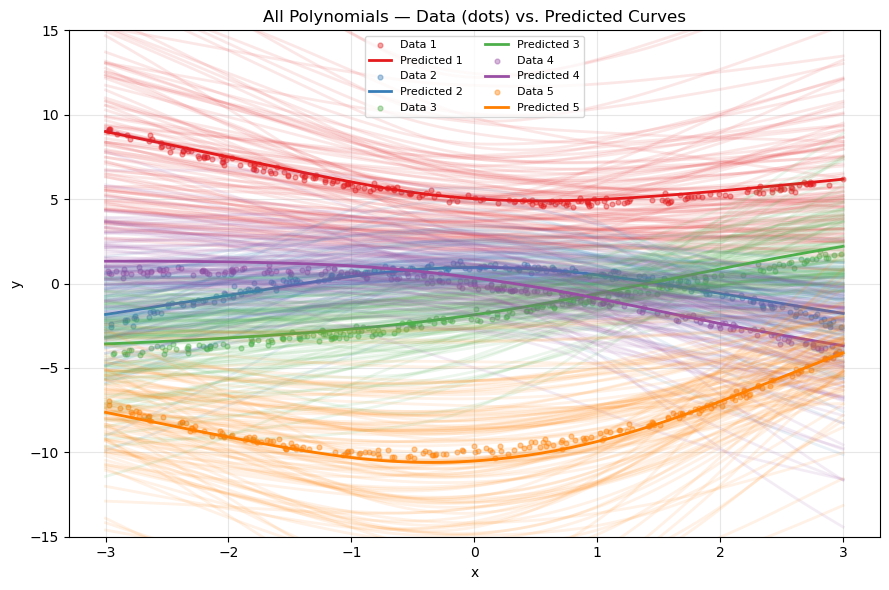

In [57]:
fig, ax = plt.subplots(figsize=(9, 6))

x_grid = torch.linspace(X_MIN, X_MAX, 150, device=device).unsqueeze(-1)

with torch.no_grad():
    for k in range(N_POLYNOMIALS):
        ax.scatter(all_x[k].squeeze().numpy(), all_y[k].squeeze().numpy(),
                  c=COLORS[k], s=12, alpha=0.4, label=f'Data {k+1}')

        C_k = torch.zeros(N_POLYNOMIALS, device=device)
        C_k[k] = 1.0
        preds = model(x_grid, samples=100, C=C_k)
        ax.plot(x_plot, preds.mean(dim=0).cpu().numpy().squeeze(), c=COLORS[k], lw=2, label=f'Predicted {k+1}')

        for i in range(100):
            y_pred = preds[i].cpu().numpy().squeeze()
            x_plot = x_grid.cpu().numpy().squeeze()
            ax.plot(x_plot, y_pred, c=COLORS[k], lw=2, alpha=0.1)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('All Polynomials — Data (dots) vs. Predicted Curves')
ax.legend(loc='best', ncol=2, fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(-15, 15)
plt.show()

## Takeaways

- The `cond_dim` parameter in `HyperNet` controls how many conditional dimensions are appended to the latent code $z$ before entering $f_\phi$.
- By passing a one-hot (or any other) condition vector $C$ at forward time, the **same** hypernetwork can produce distinct weight distributions — one per condition.
- Training with **MSE loss** for regression ensures that the model learns to predict $y$ from $x$ conditioned on $C$, producing different polynomial fits for each condition.
- This mechanism generalises naturally: $C$ can encode task IDs, domain labels, class information, or any other discrete/continuous side information.

## 5. Comparison: Conditional Variable as Input to Base Model

Notably, this task can be performed with conditional variables as input to the base model. 

We keep the **hypernetwork** but change where $C$ is used. Instead of conditioning the hypernetwork ($\theta = f_\phi([z, C])$), we pass $C$ as an **input to the base model**: $\theta = f_\phi(z)$ and $\hat{y} = f_\theta([x, C])$. The hypernetwork is unconditional; the base model sees both $x$ and $C$.

In [58]:
# Hypernetwork with C as base-model input (cond_dim=0)
base_model_C_as_x = MLP(in_channels=1 + N_POLYNOMIALS, out_channels=1,
                        hidden_channels=64, layers=2, nonlin='elu')

model_C_as_x = HyperNet(base_model_C_as_x,
                        stochastic_channels=32,
                        width=128,
                        cond_dim=0,  # No C to hypernetwork
                        nonlin='elu',
                        pz='bernoulli').to(device)

optim_C_as_x = torch.optim.Adam(model_C_as_x.parameters(), lr=1e-4)
crit = torch.nn.MSELoss()

N_EPOCHS_C_AS_X = 250
BATCH_SIZE = 256

# Input to base model: [x, C]
X_with_C = torch.cat([X, C_all], dim=1).to(device)
Y_dev = Y.to(device)

losses_C_as_x = []
for epoch in range(N_EPOCHS_C_AS_X):
    epoch_loss = 0.0
    n_batches = 0
    for idx in torch.split(torch.randperm(X_with_C.size(0), device=device), BATCH_SIZE):
        optim_C_as_x.zero_grad()
        yhat = model_C_as_x(X_with_C[idx], samples=N_SAMPLES)
        yhat_mean = yhat.mean(dim=0)
        loss = crit(yhat_mean, Y_dev[idx])
        loss.backward()
        optim_C_as_x.step()
        epoch_loss += loss.item()
        n_batches += 1
    losses_C_as_x.append(epoch_loss / n_batches)
    if (epoch + 1) % 50 == 0:
        print(f'Epoch {epoch+1:>4d}/{N_EPOCHS_C_AS_X} — loss: {losses_C_as_x[-1]:.4f}')

print('Done (hypernetwork with C as base-model input).')

Epoch   50/250 — loss: 0.6075
Epoch  100/250 — loss: 0.5082
Epoch  150/250 — loss: 0.2582
Epoch  200/250 — loss: 0.1264
Epoch  250/250 — loss: 0.1772
Done (hypernetwork with C as base-model input).


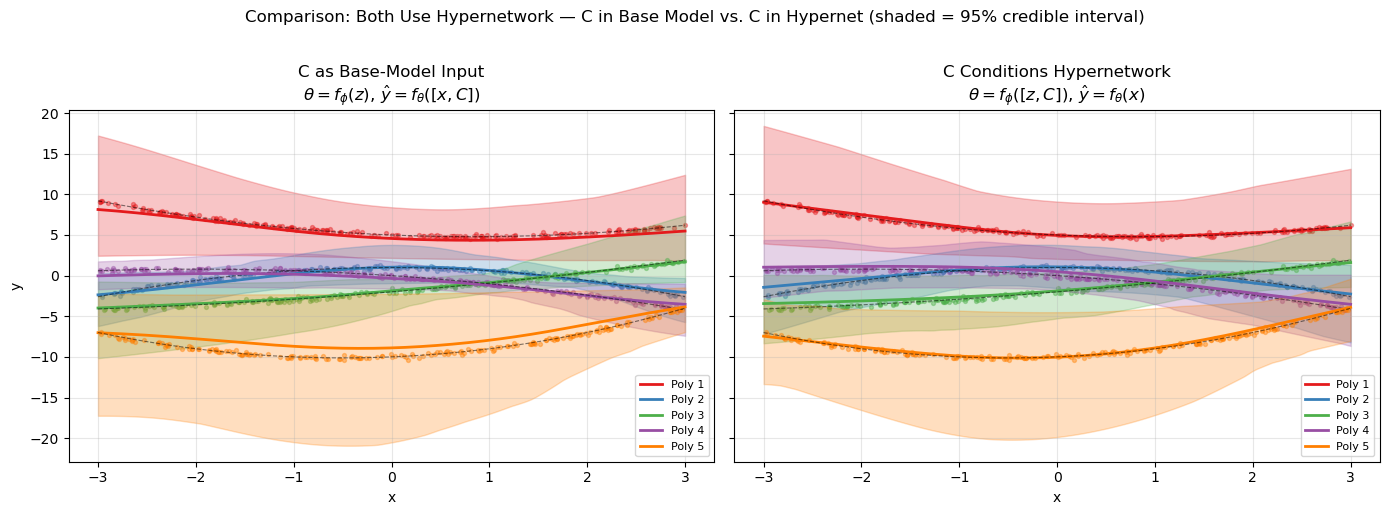

In [59]:
# Evaluate both hypernetwork variants on a fine x-grid for each condition
model_C_as_x.eval()
model.eval()

x_grid = torch.linspace(X_MIN, X_MAX, 150, device=device).unsqueeze(-1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

with torch.no_grad():
    for k in range(N_POLYNOMIALS):
        C_k = torch.zeros(N_POLYNOMIALS, device=device)
        C_k[k] = 1.0
        C_grid = C_k.unsqueeze(0).expand(x_grid.size(0), -1)
        x_with_C = torch.cat([x_grid, C_grid], dim=1)

        # C as base-model input: theta = f_phi(z), yhat = f_theta([x, C])
        preds_C_as_x = model_C_as_x(x_with_C, samples=100)
        y_C_as_x = preds_C_as_x.mean(dim=0).cpu().numpy().squeeze()
        lo_C_as_x = torch.quantile(preds_C_as_x, 0.025, dim=0).cpu().numpy().squeeze()
        hi_C_as_x = torch.quantile(preds_C_as_x, 0.975, dim=0).cpu().numpy().squeeze()

        # C conditions hypernetwork: theta = f_phi([z, C]), yhat = f_theta(x)
        preds_hnet = model(x_grid, samples=100, C=C_k)
        y_hnet = preds_hnet.mean(dim=0).cpu().numpy().squeeze()
        lo_hnet = torch.quantile(preds_hnet, 0.025, dim=0).cpu().numpy().squeeze()
        hi_hnet = torch.quantile(preds_hnet, 0.975, dim=0).cpu().numpy().squeeze()

        x_plot = x_grid.cpu().numpy().squeeze()
        a, b, c = poly_coeffs[k]
        y_true = eval_poly(torch.tensor(x_plot), a, b, c).numpy()

        # Left: C as input to base model
        axes[0].scatter(all_x[k].squeeze().numpy(), all_y[k].squeeze().numpy(),
                       c=COLORS[k], s=8, alpha=0.4)
        axes[0].fill_between(x_plot, lo_C_as_x, hi_C_as_x, color=COLORS[k], alpha=0.25)
        axes[0].plot(x_plot, y_C_as_x, c=COLORS[k], lw=2, label=f'Poly {k+1}')
        axes[0].plot(x_plot, y_true, 'k--', lw=0.8, alpha=0.5)

        # Right: C conditions hypernetwork
        axes[1].scatter(all_x[k].squeeze().numpy(), all_y[k].squeeze().numpy(),
                       c=COLORS[k], s=8, alpha=0.4)
        axes[1].fill_between(x_plot, lo_hnet, hi_hnet, color=COLORS[k], alpha=0.25)
        axes[1].plot(x_plot, y_hnet, c=COLORS[k], lw=2, label=f'Poly {k+1}')
        axes[1].plot(x_plot, y_true, 'k--', lw=0.8, alpha=0.5)

axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('C as Base-Model Input\n$\\theta = f_\\phi(z)$, $\\hat{y} = f_\\theta([x, C])$')
axes[0].legend(loc='best', fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('x')
axes[1].set_title('C Conditions Hypernetwork\n$\\theta = f_\\phi([z, C])$, $\\hat{y} = f_\\theta(x)$')
axes[1].legend(loc='best', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Comparison: Both Use Hypernetwork — C in Base Model vs. C in Hypernet (shaded = 95% credible interval)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### Performance vs. True Function

We evaluate both models on held-out $x$ values, comparing predictions to the noiseless true polynomial. **R²** measures explained variance, **MSE** the squared error, **ECE** (Expected Calibration Error) how well the predictive intervals match empirical coverage, and **MPIW** (Mean Predicted Interval Width) the average width of the 90% credible interval.

In [60]:
# Compare performance vs. true function: R2, ECE, MSE, MPIW
def r2_score(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true).flatten(), np.asarray(y_pred).flatten()
    ss_res = ((y_true - y_pred) ** 2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum()
    return 1 - (ss_res / (ss_tot + 1e-8))

def ece_regression(y_true, pred_samples, intervals=[(0.25, 0.75), (0.1, 0.9), (0.05, 0.95)]):
    """ECE: mean of |empirical coverage - nominal coverage| over interval levels.
    pred_samples: (n_samples, n_points) or (n_samples, n_points, 1)"""
    pred_samples = np.asarray(pred_samples)
    if pred_samples.ndim == 3:
        pred_samples = pred_samples.squeeze(-1)  # (n_samples, n_points)
    y_true = np.asarray(y_true).flatten()
    nominal, empirical = [], []
    for lo, hi in intervals:
        pred_lo = np.quantile(pred_samples, lo, axis=0)
        pred_hi = np.quantile(pred_samples, hi, axis=0)
        in_interval = (y_true >= pred_lo) & (y_true <= pred_hi)
        coverage = in_interval.mean()
        nominal.append(hi - lo)
        empirical.append(coverage)
    return np.mean(np.abs(np.array(empirical) - np.array(nominal)))

def mpiw(pred_samples, coverage=0.9):
    """Mean Predicted Interval Width: mean(hi - lo) over test points at given coverage."""
    pred_samples = np.asarray(pred_samples)
    if pred_samples.ndim == 3:
        pred_samples = pred_samples.squeeze(-1)
    lo = (1 - coverage) / 2
    hi = 1 - lo
    pred_lo = np.quantile(pred_samples, lo, axis=0)
    pred_hi = np.quantile(pred_samples, hi, axis=0)
    return np.mean(pred_hi - pred_lo)

n_eval = 500
np.random.seed(123)
x_eval = torch.rand(n_eval, 1, device=device) * (X_MAX - X_MIN) + X_MIN

results = []
with torch.no_grad():
    for k in range(N_POLYNOMIALS):
        a, b, c = poly_coeffs[k]
        # True function (noiseless)
        y_true = eval_poly(x_eval.squeeze(), a, b, c).unsqueeze(-1).cpu().numpy()
        C_k = torch.zeros(N_POLYNOMIALS, device=device)
        C_k[k] = 1.0
        x_with_C = torch.cat([x_eval, C_k.unsqueeze(0).expand(n_eval, -1)], dim=1)

        # C as base-model input
        preds_C = model_C_as_x(x_with_C, samples=200)
        preds_C_np = preds_C.cpu().numpy()
        y_C = preds_C.mean(dim=0).cpu().numpy()
        mse_C = np.mean((y_true - y_C) ** 2)
        r2_C = r2_score(y_true, y_C)
        ece_C = ece_regression(y_true, preds_C_np)
        mpiw_C = mpiw(preds_C_np, coverage=0.9)

        # C conditions hypernetwork
        preds_H = model(x_eval, samples=200, C=C_k)
        preds_H_np = preds_H.cpu().numpy()
        y_H = preds_H.mean(dim=0).cpu().numpy()
        mse_H = np.mean((y_true - y_H) ** 2)
        r2_H = r2_score(y_true, y_H)
        ece_H = ece_regression(y_true, preds_H_np)
        mpiw_H = mpiw(preds_H_np, coverage=0.9)

        results.append({'poly': k+1, 'MSE_C': mse_C, 'R2_C': r2_C, 'ECE_C': ece_C, 'MPIW_C': mpiw_C,
                        'MSE_H': mse_H, 'R2_H': r2_H, 'ECE_H': ece_H, 'MPIW_H': mpiw_H})

# Summary table
import pandas as pd
df = pd.DataFrame(results)
df_summary = pd.DataFrame({
    'C as input': [df['MSE_C'].mean(), df['R2_C'].mean(), df['ECE_C'].mean(), df['MPIW_C'].mean()],
    'C conditions hnet': [df['MSE_H'].mean(), df['R2_H'].mean(), df['ECE_H'].mean(), df['MPIW_H'].mean()]
}, index=['MSE', 'R2', 'ECE', 'MPIW (90%)'])
print('Performance vs. true function (mean over polynomials):')
print(df_summary.round(4))
print()
print('Per-polynomial breakdown:')
print(df.round(4))

Performance vs. true function (mean over polynomials):
            C as input  C conditions hnet
MSE             0.3699             0.1649
R2              0.8311             0.8840
ECE             0.2653             0.2643
MPIW (90%)      5.9540             6.9250

Per-polynomial breakdown:
   poly   MSE_C    R2_C   ECE_C   MPIW_C   MSE_H    R2_H   ECE_H  MPIW_H
0     1  0.2064  0.8484  0.2667   7.1398  0.5896  0.5671  0.2667  9.2272
1     2  0.0968  0.9145  0.2600   3.2804  0.1100  0.9029  0.2547  5.2770
2     3  0.0125  0.9960  0.2667   4.3802  0.0251  0.9919  0.2667  5.3040
3     4  0.1345  0.9402  0.2667   3.0347  0.0559  0.9751  0.2667  5.2249
4     5  1.3991  0.4565  0.2667  11.9349  0.0438  0.9830  0.2667  9.5917


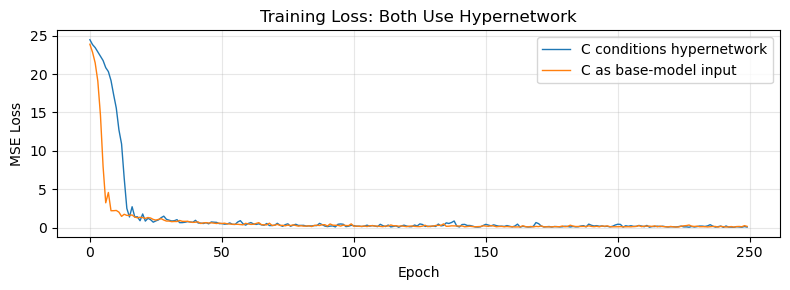

In [61]:
# Training loss comparison
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses, lw=1, label='C conditions hypernetwork')
ax.plot(losses_C_as_x, lw=1, label='C as base-model input')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training Loss: Both Use Hypernetwork')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Takeaways from Comparison

- **C as base-model input**: $\theta = f_\phi(z)$, $\hat{y} = f_\theta([x, C])$. The hypernetwork is unconditional; the base model receives $C$ as a feature alongside $x$. Still yields an ensemble over $z$.
- **C conditions hypernetwork**: $\theta = f_\phi([z, C])$, $\hat{y} = f_\theta(x)$. The hypernetwork produces *different weights* for each $C$; the base model sees only $x$.
- Both use a hypernetwork; they differ only in where $C$ is applied—either as input to the base model or as input to the hypernetwork.